In [1]:
import os
from typing import TypedDict, List, Literal, Optional
from dotenv import load_dotenv

load_dotenv()

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.callbacks import BaseCallbackHandler
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

llm = ChatOpenAI(model="gpt-4o-mini")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [2]:
# adaptive rag : 쿼리 -> 검색을 할지 말지
# self rag : retrieved 문서 

In [3]:
class SelfRAGState(TypedDict):
    question : str
    rewritten_question: str  # C-RAG 
    documents : List[Document]
    filtered_documents : List[Document]
    generation : str
    relevance_grades : List[str]
    hallucination_score : str
    usefulness_score : int
    relevance_retries : int
    generation_retries : int
    max_tries : int

In [4]:
builder = StateGraph(SelfRAGState)
builder.add_edge(START, END)
app = builder.compile()

In [5]:
DOCS = [
    Document(page_content="Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.",
             metadata={"src": "selfrag-intro"}),
    Document(page_content="원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.",
             metadata={"src": "selfrag-paper"}),
    Document(page_content="구현체는 LLM-as-judge 패턴(with_structured_output)으로 reflection token을 대신합니다.",
             metadata={"src": "selfrag-impl"}),
    Document(page_content="관련성 평가에서 yes 문서만 컨텍스트로 추리고, 모두 no면 쿼리 재작성 또는 재검색.",
             metadata={"src": "selfrag-relevance"}),
    Document(page_content="환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.",
             metadata={"src": "selfrag-hallucination"}),
    Document(page_content="유용성 평가는 답변이 질문에 정말 답하는지 1-5점으로 매깁니다. 3점 미만이면 재생성.",
             metadata={"src": "selfrag-usefulness"}),
    Document(page_content="LangGraph는 StateGraph로 노드와 조건부 엣지를 조립해 평가 루프를 자연스럽게 표현합니다.",
             metadata={"src": "langgraph"}),
    Document(page_content="쿼리 재작성은 검색 실패 시 동의어/구체화로 쿼리를 바꿔 다시 검색하는 폴백 패턴입니다.",
             metadata={"src": "query-rewrite"}),
]
vectorstore = FAISS.from_documents(DOCS, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

In [6]:
def retrieve_node(state : SelfRAGState) -> dict:
    docs = retriever.invoke(state['question'])
    return {'documents' : docs}

In [7]:
INIT = {"question": "", "rewritten_question": "",
        "documents": [], "filtered_documents": [], "generation": "",
        "relevance_grades": [], "hallucination_score": "",
        "usefulness_score": 0,
        "relevance_retries": 0, "generation_retries": 0, "max_retries": 4}

In [8]:
builder = StateGraph(SelfRAGState)
builder.add_node('retrieve', retrieve_node)
builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', END)
app = builder.compile()

In [9]:
result = app.invoke({**INIT, "question" : 'self-rag의 환각 평가는 어떻게 하나요?'})
result

{'question': 'self-rag의 환각 평가는 어떻게 하나요?',
 'rewritten_question': '',
 'documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.'),
  Document(id='49659915-47a1-4cbb-9828-cdc0aa1bd1dc', metadata={'src': 'selfrag-hallucination'}, page_content='환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.')],
 'filtered_documents': [],
 'generation': '',
 'relevance_grades': [],
 'hallucination_score': '',
 'usefulness_score': 0,
 'relevance_retries': 0,
 'generation_retries': 0}

In [10]:
RAG_PROMPT = ChatPromptTemplate.from_messages([
    ('system', "다음 문서를 근거로 한국어로 간단히 답하세요. 문서에 없으면 '모름'이라고 답하세요"),
    ('human', "질문 : {question}\n\n문서:\n{context}")
])

def generate_node(state : SelfRAGState) -> dict:
    ctx = '\n'.join(f" - {d.page_content}" for d in state['documents'])
    msg = RAG_PROMPT.format_messages(question = state['question'], context = ctx)
    return {'generation' : llm.invoke(msg).content}

In [11]:
builder = StateGraph(SelfRAGState)
builder.add_node('retrieve', retrieve_node)
builder.add_node('generate', generate_node)
builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'generate')
builder.add_edge('generate', END)
app = builder.compile()

In [12]:
result = app.invoke({**INIT, 'question' : 'self-rag의 유용성 평가 기준은?'})
result

{'question': 'self-rag의 유용성 평가 기준은?',
 'rewritten_question': '',
 'documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.'),
  Document(id='eecf8783-e9ab-49b4-8754-607a0bbb7baa', metadata={'src': 'selfrag-usefulness'}, page_content='유용성 평가는 답변이 질문에 정말 답하는지 1-5점으로 매깁니다. 3점 미만이면 재생성.')],
 'filtered_documents': [],
 'generation': 'self-RAG의 유용성 평가 기준은 답변이 질문에 정말 답하는지를 1-5점으로 매기는 것입니다. 3점 미만일 경우 재생성합니다.',
 'relevance_grades': [],
 'hallucination_score': '',
 'usefulness_score': 0,
 'relevance_retries': 0,
 'generation_retries': 0}

In [13]:
# retrieve -> grade_relevance -> generate

In [14]:
class _Relevance(BaseModel):
    binary : Literal['yes', 'no'] = Field(description='문서가 질문과 관련이 있는지')

relevance_grader = llm.with_structured_output(_Relevance)

REL_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "당신은 문서가 질문과 관련 있는지 평가하는 전문가입니다. yes/no 로만 반환해주세요"),
    ("human", "질문: {question}\n문서: {doc}")
])

def grade_relevance_node(state : SelfRAGState) -> dict:
    # llm documents를 평가해서 relevant 여부를 yes/no 답변
    grades = []
    for d in state['documents']:
        msg = REL_PROMPT.format_messages(question = state['question'], doc = d.page_content) # yes, no, yes입니다, no. , 
        grades.append(relevance_grader.invoke(msg).binary)
    return {'relevance_grades' : grades}

In [15]:
builder = StateGraph(SelfRAGState)
builder.add_node('retrieve', retrieve_node)
builder.add_node('grade_relevance', grade_relevance_node)
builder.add_node('generate', generate_node)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_edge('grade_relevance', 'generate')
builder.add_edge('generate', END)
app = builder.compile()

In [16]:
result = app.invoke({**INIT, 'question' : 'self-rag의 유용성 평가 기준은?'})

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Relevance(binary='yes'), input_type=_Relevance])
  return self.__pydantic_serializer__.to_python(
/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Relevance(binary='no'), input_type=_Relevance])
  return self.__pydantic_serializer__.to_python(


In [17]:
result

{'question': 'self-rag의 유용성 평가 기준은?',
 'rewritten_question': '',
 'documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.'),
  Document(id='eecf8783-e9ab-49b4-8754-607a0bbb7baa', metadata={'src': 'selfrag-usefulness'}, page_content='유용성 평가는 답변이 질문에 정말 답하는지 1-5점으로 매깁니다. 3점 미만이면 재생성.')],
 'filtered_documents': [],
 'generation': 'Self-RAG의 유용성 평가 기준은 답변이 질문에 정말 답하는지를 1-5점으로 매기는 것입니다. 3점 미만일 경우 재생성합니다.',
 'relevance_grades': ['yes', 'yes', 'no'],
 'hallucination_score': '',
 'usefulness_score': 0,
 'relevance_retries': 0,
 'generation_retries': 0}

In [18]:
result = app.invoke({**INIT, 'question' : '제로콜라 가격은?'})

In [19]:
result

{'question': '제로콜라 가격은?',
 'rewritten_question': '',
 'documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='489bb344-80cd-40af-bcbe-53e835ad3237', metadata={'src': 'selfrag-relevance'}, page_content='관련성 평가에서 yes 문서만 컨텍스트로 추리고, 모두 no면 쿼리 재작성 또는 재검색.'),
  Document(id='d3a68452-4ef4-4698-bf95-3de8617b651a', metadata={'src': 'query-rewrite'}, page_content='쿼리 재작성은 검색 실패 시 동의어/구체화로 쿼리를 바꿔 다시 검색하는 폴백 패턴입니다.')],
 'filtered_documents': [],
 'generation': '모름',
 'relevance_grades': ['no', 'no', 'no'],
 'hallucination_score': '',
 'usefulness_score': 0,
 'relevance_retries': 0,
 'generation_retries': 0}

In [20]:
# retrieve -> grade_relevance -> router  -관련된 문서가 있음-> generate
#       ^                            |
#       ------------관련문서없음------|


In [21]:
def grade_relevance_node(state : SelfRAGState) -> dict:
    # llm documents를 평가해서 relevant 여부를 yes/no 답변
    grades = []
    for d in state['documents']:
        msg = REL_PROMPT.format_messages(question = state['question'], doc = d.page_content) # yes, no, yes입니다, no. , 
        grades.append(relevance_grader.invoke(msg).binary)
    return {'relevance_grades' : grades}

In [22]:
def grade_and_filter_node(state : SelfRAGState) -> dict:
    grades, keep = [], []
    for d in state['documents']:
        msg = REL_PROMPT.format_messages(question = state['question'], doc = d.page_content)
        g = relevance_grader.invoke(msg).binary
        grades.append(g)
        if g == 'yes':
            keep.append(d)
    return {'relevance_grades' : grades, 'filtered_documents' : keep}

def generate_filtered_node(state : SelfRAGState) -> dict:
    ctx = '\n'.join(f" - {d.page_content}" for d in state['filtered_documents'])
    msg = RAG_PROMPT.format_messages(question = state['question'], context = ctx)
    return {'generation' : llm.invoke(msg).content}

def relevance_router(state : SelfRAGState) -> dict:
    return "generate" if state['filtered_documents'] else "retrieve"

In [23]:
# def grade_and_filter_with_counter_node(state : SelfRAGState) -> dict:
#     grades, keep = [], []
#     for d in state['documents']:
#         msg = REL_PROMPT.format_messages(question = state['question'], doc = d.page_content)
#         g = relevance_grader.invoke(msg).binary
#         grades.append(g)
#         if g == 'yes':
#             keep.append(d)
#     return {'relevance_grades' : grades, 'filtered_documents' : keep, 'relevance_retries' : state['relevance_retries'] + 1}  

# def safe_relevance_router(state : SelfRAGState) -> dict:
#     if state['relevance_retries'] >=2:
#         return 'generate'
#     return "generate" if state['filtered_documents'] else "retrieve"

In [24]:
builder = StateGraph(SelfRAGState)
builder.add_node('retrieve', retrieve_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('generate', generate_filtered_node)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', relevance_router, {'generate' : 'generate', 'retrieve' : 'retrieve'})
builder.add_edge('generate', END)
app = builder.compile()

In [25]:
result = app.invoke({**INIT, 'question' : 'self-rag의 관련성 평가는?'})

In [26]:
result

{'question': 'self-rag의 관련성 평가는?',
 'rewritten_question': '',
 'documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.'),
  Document(id='eecf8783-e9ab-49b4-8754-607a0bbb7baa', metadata={'src': 'selfrag-usefulness'}, page_content='유용성 평가는 답변이 질문에 정말 답하는지 1-5점으로 매깁니다. 3점 미만이면 재생성.')],
 'filtered_documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'generation': 'Self-RAG의 관련성 평가는 LLM이 스스로 판단하는 자가 평가 방식으로, 검색 여부와 답변 품질을 표시하기 위해 reflection token을 학습합니

In [27]:
# result = app.invoke({**INIT, 'question' : '제로콜라의 가격은?'})

In [28]:
# retrieve -> grade_relevance -> router -> generate -> END
#  ^                               |
# ----------rewrite query----------

In [29]:
class SelfRAGState(TypedDict):
    question : str
    rewritten_question: str  # C-RAG 
    documents : List[Document]
    filtered_documents : List[Document]
    generation : str
    relevance_grades : List[str]
    hallucination_score : str
    usefulness_score : int
    relevance_retries : int
    generation_retries : int
    max_tries : int

In [30]:
REWRITE_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "다음 질문을 의미는 보존하되 검색이 더 잘 되도록 동의어, 구체화로 재작성해줘. 한 줄로만."),
    ("human", "원래 질문: {question}")
])

def rewrite_query_node(state : SelfRAGState) -> dict :
    msg = REWRITE_PROMPT.format_messages(question = state['question'])
    new_q = llm.invoke(msg).content.strip()
    return {'rewritten_question' : new_q} # 제로콜라 얼마지?

def retrieve_aware_node(state : SelfRAGState) -> dict :
    q = state['rewritten_question'] or state['question']
    return {'documents' : retriever.invoke(q)}

def relevance_router(state : SelfRAGState) -> dict:
    if state['filtered_documents']:
        return 'generate'
    return 'rewrite_query'
    

In [31]:
builder = StateGraph(SelfRAGState)
builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_node)
builder.add_node('generate', generate_filtered_node)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', relevance_router, {'generate' : 'generate', 'rewrite_query' : 'rewrite_query'})
builder.add_edge('rewrite_query', 'retrieve')
builder.add_edge('generate', END)
app = builder.compile()

In [32]:
# result = app.invoke({**INIT, 'question' : '제로콜라 가격은?'})

In [33]:
# rewrite_query : 쿼리 재작성 횟수는 최대 1회

In [34]:
def rewrite_with_counter(state : SelfRAGState) -> dict:
    msg = REWRITE_PROMPT.format_messages(question = state['question'])
    return {'rewritten_question' : llm.invoke(msg).content.strip(), 'relevance_retries' : state['relevance_retries'] +1}
def bounded_router(state : SelfRAGState) -> dict:
    if state['filtered_documents']:
        return 'generate'
    if state['relevance_retries'] <1:
        return 'rewrite_query'
    return 'generate'

In [35]:
# retrieve -> grade_relevance -> router -> generate -> grade_hallucination -> END
#  ^                               |
# ----------rewrite query----------

In [36]:
class _Hallucination(BaseModel):
    binary : Literal['yes', 'no'] = Field(description='답변이 환각인지 (yes = 문서 밖 정보, no = 근거 있음)')

hallucination_grader = llm.with_structured_output(_Hallucination)

HAL_PROMT = ChatPromptTemplate.from_messages([
    ("system", "당신은 엄격한 채점관입니다. 답변의 모든 사실이 문서에 명시적으로 있어야 no. 일반 지식, 문서 밖 정보가 있으면 yes(환각), 근거하면 no"),
    ("human", "문서: \n{context}\n\n답변: {answer}")
])

def grade_hallucination_node(state : SelfRAGState) -> dict:
    docs = state['filtered_documents'] or state['docments']
    ctx = '\n'.join(d.page_content for d in docs)
    msg = HAL_PROMT.format_messages(context = ctx, answer = state['generation'])
    return {'hallucination_score' : hallucination_grader.invoke(msg).binary}

In [37]:
builder = StateGraph(SelfRAGState)
builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_node)
builder.add_node('generate', generate_filtered_node)
builder.add_node('grade_hallucination', grade_hallucination_node)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', relevance_router, {'generate' : 'generate', 'rewrite_query' : 'rewrite_query'})
builder.add_edge('rewrite_query', 'retrieve')
builder.add_edge('generate', 'grade_hallucination')
builder.add_edge('grade_hallucination', END)
app = builder.compile()

In [38]:
result = app.invoke({**INIT, 'question' : 'self-rag 환각 평가는 어떻게 하나요?'})

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Hallucination(binary='no'), input_type=_Hallucination])
  return self.__pydantic_serializer__.to_python(


In [39]:
result

{'question': 'self-rag 환각 평가는 어떻게 하나요?',
 'rewritten_question': '',
 'documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='49659915-47a1-4cbb-9828-cdc0aa1bd1dc', metadata={'src': 'selfrag-hallucination'}, page_content='환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'filtered_documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.')],
 'generation': '모름',
 'relevance_grades': ['yes', 'no', 'no'],
 'hallucination_score': 'no',
 'usefulness_score': 0,
 'relevance_retries': 0,
 'generation_retries': 0}

In [43]:
def generate_with_counter(state : SelfRAGState) -> dict:
    docs = state['filtered_documents'] or state['documents']
    ctx = '\n'.join(f"- {d.page_content}" for d in docs)
    msg = RAG_PROMPT.format_messages(question=state['question'], context= ctx)
    return {'generation' : llm.invoke(msg).content, 'generation_retries' : state['generation_retries'] + 1}

def hallucination_router(state : SelfRAGState) -> str:
    if state['generation_retries'] >=2 :
        return 'end'
    return 'generate' if ['hallucination_score'] == 'yes' else 'end'

In [ ]:
#1. re-generate : llm  temperature = 0.7  initialize한 새로운 llm으로 생성
#2. 재생성을 하는데, "이전 답변은 환각이었습니다. 문서에 의존해서 다시 답변"

In [44]:
# retrieve -> grade_relevance -> router -> generate -> grade_hallucination -> END
#  ^                               |
# ----------rewrite query----------

In [45]:
builder = StateGraph(SelfRAGState)
builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_node)
builder.add_node('generate', generate_with_counter)
builder.add_node('grade_hallucination', grade_hallucination_node)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', relevance_router, {'generate' : 'generate', 'rewrite_query' : 'rewrite_query'})
builder.add_edge('rewrite_query', 'retrieve')
builder.add_edge('generate', 'grade_hallucination')
builder.add_conditional_edges('grade_hallucination', hallucination_router, {'generate' : 'generate', 'end' : END})
app = builder.compile()

In [46]:
result = app.invoke({**INIT, 'question' : 'self-rag 환각 평가는?'})

In [47]:
result

{'question': 'self-rag 환각 평가는?',
 'rewritten_question': '',
 'documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='49659915-47a1-4cbb-9828-cdc0aa1bd1dc', metadata={'src': 'selfrag-hallucination'}, page_content='환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'filtered_documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'generation': 'Self-RAG 환각 평가는 LLM이 스스로 검색 및 답변 품질을 판단하는 자가 평가 방식입니다.',
 'relevance_grades': ['yes', 'no'

In [48]:
llm_temp = ChatOpenAI(model='gpt-4o-mini', temperature = 0.7)
def generate_1_temp(question, docs):
    ctx = '\n'.join(f"- {d.page_content}" for d in docs)
    return llm_temp.invoke(RAG_PROMPT.format_messages(question=question, context=ctx)).context

HALLUCINATION_PROMPT = ChatPromptTemplate.from_messages([
    ('system', '이전은 환각이었습니다'),
    ('human', '질문 : {question}\n\n문서 : \n{context}')
])
def generate_2_hallucination(question, docs):
    ctx = '\n'.join(f"- {d.page_content}" for d in docs)
    return llm.invoke(HALLUCINATION_PROMPT.format_messages(question=question, ctx= ctx)).content

In [ ]:
# usefulness : 

In [ ]:
class SelfRAGState(TypedDict):
    question : str
    rewritten_question: str  # C-RAG 
    documents : List[Document]
    filtered_documents : List[Document]
    generation : str
    relevance_grades : List[str]
    hallucination_score : str
    usefulness_score : int
    relevance_retries : int
    generation_retries : int
    max_tries : int

In [49]:
class _Usefulness(BaseModel):
    score : int = Field(description='답변의 유용성 1~5점', ge=1, le=5)

usefulness_grader = llm.with_structured_output(_Usefulness)

USE_PROMPT = ChatPromptTemplate.from_messages([
    ('system', '답변이 질문에 얼마나 잘 답하는지 1~5점으로 평가. 1=관련 없음, 2=약함, 3=보통, 4=좋음, 5=완벽'),
    ('human' , '질문: {question}\n답변: {answer}')
])

def grade_usefulness_node(state : SelfRAGState) -> dict:
    msg = USE_PROMPT.format_messages(question= state['question'], answer=state['generation'])
    return {'usefulness_score' : usefulness_grader.invoke(msg).score}

In [56]:
Q = "Self-RAG란?"
answers = {
    'good' : 'Self-RAG 는 검색,생성, 평가를 LLM이 스스로 판단하는 자가평가 RAG입니다',
    'bad' :'잘 모르겠어요',
    'unrelated' : '오늘 날씨가 좋네요'
}

scores = {}
for label, ans in answers.items():
    msg = USE_PROMPT.format_messages(question=Q, answer=ans)
    scores[label] = usefulness_grader.invoke(msg).score
    
print(scores)

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Usefulness(score=1), input_type=_Usefulness])
  return self.__pydantic_serializer__.to_python(


{'good': 3, 'bad': 1, 'unrelated': 1}


In [ ]:
# retrieve -> grade_relevance -> router -> generate -> grade_hallucination -> router -> grade_usefulness_node  -> router ->  END
#  ^                               |        |                                  |
# ----------rewrite query----------         |-----------------------------------

# 5점 -> END
# 3~4점 -> generate
# 1~2점 -> retrieve

In [53]:
def hallucination_router(state : SelfRAGState) -> str:
    if state['generation_retries'] >=2 :
        return 'usefulness'
    return 'generate' if ['hallucination_score'] == 'yes' else 'usefulness'

In [54]:
builder = StateGraph(SelfRAGState)
builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_node)
builder.add_node('generate', generate_with_counter)
builder.add_node('grade_hallucination', grade_hallucination_node)
builder.add_node('grade_usefulness', grade_usefulness_node)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', relevance_router, {'generate' : 'generate', 'rewrite_query' : 'rewrite_query'})
builder.add_edge('rewrite_query', 'retrieve')
builder.add_edge('generate', 'grade_hallucination')
builder.add_conditional_edges('grade_hallucination', hallucination_router, {'generate' : 'generate', 'usefulness' : 'grade_usefulness'})
builder.add_edge('grade_usefulness', END)
app = builder.compile()

In [55]:
result = app.invoke({**INIT, 'question' : 'self-rag 환각 평가는?'})
result

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Usefulness(score=3), input_type=_Usefulness])
  return self.__pydantic_serializer__.to_python(


{'question': 'self-rag 환각 평가는?',
 'rewritten_question': '',
 'documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='49659915-47a1-4cbb-9828-cdc0aa1bd1dc', metadata={'src': 'selfrag-hallucination'}, page_content='환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'filtered_documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='49659915-47a1-4cbb-9828-cdc0aa1bd1dc', metadata={'src': 'selfrag-hallucination'}, page_content='환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Sel

In [ ]:
# retrieve -> grade_relevance -> router -> generate -> grade_hallucination -> router -> grade_usefulness_node  -> router ->  END
#  ^                               |        |                                  |
# ----------rewrite query----------         |-----------------------------------

# 5점 -> END
# 3~4점 -> generate
# 1~2점 -> retrieve

In [ ]:
class SelfRAGState(TypedDict):
    question : str
    rewritten_question: str  # C-RAG 
    documents : List[Document]
    filtered_documents : List[Document]
    generation : str
    relevance_grades : List[str]
    hallucination_score : str
    usefulness_score : int
    relevance_retries : int
    generation_retries : int
    max_tries : int

In [61]:
def usefulness_router(state : SelfRAGState) -> dict:
    # 무한루프 방지
    s = state['usefulness_score']
    if state['generation_retries'] >=3 or state['relevance_retries'] >=2:
        return 'end'
    if s >=5:
        return 'end'
    if s>=3:
        return 'regenerate'
    return 'reretrieve'

In [62]:
builder = StateGraph(SelfRAGState)
builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_node)
builder.add_node('generate', generate_with_counter)
builder.add_node('grade_hallucination', grade_hallucination_node)
builder.add_node('grade_usefulness', grade_usefulness_node)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', relevance_router, {'generate' : 'generate', 'rewrite_query' : 'rewrite_query'})
builder.add_edge('rewrite_query', 'retrieve')
builder.add_edge('generate', 'grade_hallucination')
builder.add_conditional_edges('grade_hallucination', hallucination_router, {'generate' : 'generate', 'usefulness' : 'grade_usefulness'})
builder.add_conditional_edges('grade_usefulness', usefulness_router, {'end' : END, 'regenerate' : 'generate', 'reretrieve' : 'retrieve'})
app = builder.compile()

In [ ]:
# retrieve -> grade_relevance -> router -> generate -> grade_hallucination -> router -> grade_usefulness_node  -> router ->  END
#  ^                               |        |                                  |
# ----------rewrite query----------         |-----------------------------------

# 5점 -> END
# 3~4점 -> generate
# 1~2점 -> retrieve

In [68]:
class SelfRAGState(TypedDict):
    question : str
    rewritten_question: str  # C-RAG 
    documents : List[Document]
    filtered_documents : List[Document]
    generation : str
    relevance_grades : List[str]
    hallucination_score : str
    usefulness_score : int
    relevance_retries : int
    generation_retries : int
    max_tries : int 
    max_retries : int

In [69]:
def safe_relevance_router(state : SelfRAGState) -> str:
    if state['relevance_retries'] >= state['max_retries']:  
        return 'generate'
    if state['filtered_documents']:
        return 'generate'
    return 'rewrite_query'

def safe_hallucination_router(state : SelfRAGState) -> str:
    if state['generation_retries'] >= state['max_retries']:
        return 'usefulness'
    return 'generate' if state['hallucination_score'] == 'yes' else 'usefulness'

def safe_usefulness_router(state : SelfRAGState) -> str:
    s = state['usefulness_score']
    if state['generation_retries'] >=state['max_retries'] or state['relevance_retries'] >=state['max_retries']:
        return 'end'
    if s >=5:
        return 'end'
    if s>=3:
        return 'regenerate'
    return 'reretrieve'

def rewrite_query_counter(state : SelfRAGState) -> dict:
    msg = REWRITE_PROMPT.format_messages(question = state['question'])
    return {'rewritten_question' : llm.invoke(msg).content.strip(), 'relevance_retries' : state['relevance_retries'] + 1}

In [70]:
builder = StateGraph(SelfRAGState)
builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_counter)
builder.add_node('generate', generate_with_counter)
builder.add_node('grade_hallucination', grade_hallucination_node)
builder.add_node('grade_usefulness', grade_usefulness_node)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', safe_relevance_router, {'generate' : 'generate', 'rewrite_query' : 'rewrite_query'})
builder.add_edge('rewrite_query', 'retrieve')
builder.add_edge('generate', 'grade_hallucination')
builder.add_conditional_edges('grade_hallucination', safe_hallucination_router, {'generate' : 'generate', 'usefulness' : 'grade_usefulness'})
builder.add_conditional_edges('grade_usefulness', safe_usefulness_router, {'end' : END, 'regenerate' : 'generate', 'reretrieve' : 'retrieve'})
app = builder.compile()

In [71]:
result = app.invoke({**INIT, 'question' : 'self-rag의 핵심은?', 'max_retries' : 4})

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Usefulness(score=4), input_type=_Usefulness])
  return self.__pydantic_serializer__.to_python(
/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_Usefulness(score=5), input_type=_Usefulness])
  return self.__pydantic_serializer__.to_python(


In [72]:
result

{'question': 'self-rag의 핵심은?',
 'rewritten_question': '',
 'documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.'),
  Document(id='d1718cb3-f17c-4271-bd94-3fbe1f6dec8a', metadata={'src': 'selfrag-impl'}, page_content='구현체는 LLM-as-judge 패턴(with_structured_output)으로 reflection token을 대신합니다.')],
 'filtered_documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'generation': 'Self-RAG의 핵심은 LLM이 스스로 검색, 생성, 평가를 판단하는 자가 평가 RAG라는 점입니다.',
 'relevance_grad

In [73]:
for chunk in app.stream({**INIT, 'question' : 'self-rag의 핵심은?', 'max_retries' : 4}):
    for node_name, payload in chunk.items():
        print(node_name, payload)

retrieve {'documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'), Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.'), Document(id='d1718cb3-f17c-4271-bd94-3fbe1f6dec8a', metadata={'src': 'selfrag-impl'}, page_content='구현체는 LLM-as-judge 패턴(with_structured_output)으로 reflection token을 대신합니다.')]}
grade_relevance {'relevance_grades': ['yes', 'yes', 'no'], 'filtered_documents': [Document(id='36e10dc9-5a2b-4afe-8606-39ef2326f42c', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'), Document(id='22f40607-1381-451b-ba30-93e2652e4801', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')]}
generate {'generation': 'self-RAG의 핵심은 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.', 'generatio

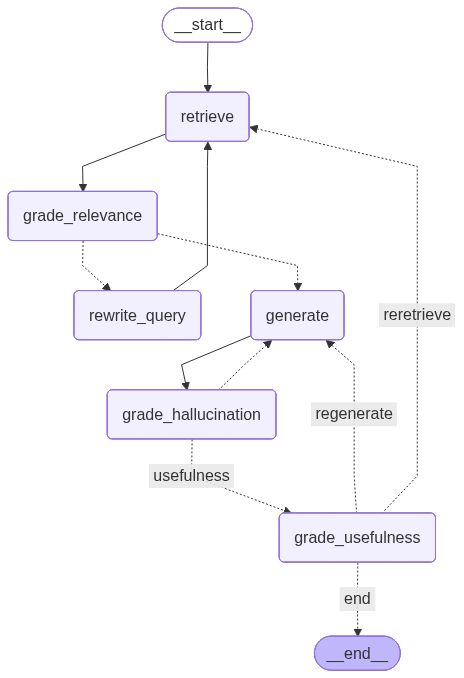

In [76]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# C-RAG Corrective RAG
# adaptive rag : query 난이도를 scoring
# self-rag : self evaluate
# CRAG : Corrective RAG -> query rewrite, relevance - correct / ambiguous / incorrect

In [77]:
class _CragGrade(BaseModel):
    """검색 결과의 신뢰도를 3단계로 평가."""
    grade: Literal["correct", "ambiguous", "incorrect"] = Field(
        description="correct=자신있음, ambiguous=부분적, incorrect=무관"
    )
    score: float = Field(ge=0.0, le=1.0, description="0~1 신뢰도 점수")

crag_grader = llm.with_structured_output(_CragGrade)

CRAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "당신은 검색 결과의 질문 적합도를 평가하는 전문가입니다. "
               "correct(>=0.7), ambiguous(0.3~0.7), incorrect(<0.3) 중 하나로 등급 + 점수."),
    ("human", "질문: {question}\n\n검색된 문서:\n{docs}\n\n등급과 점수를 매기세요."),
])

def crag_grade_node(state: SelfRAGState) -> dict:
    docs = state.get("filtered_documents") or state["documents"]
    if not docs:
        return {"crag_grade": "incorrect", "crag_score": 0.0}
    ctx = "\n---\n".join(d.page_content for d in docs[:5])
    r = crag_grader.invoke(CRAG_PROMPT.format_messages(question=state["question"], docs=ctx))
    return {"crag_grade": r.grade, "crag_score": r.score}



In [78]:
result = crag_grade_node({**INIT, 'question': 'Self-rag의 환각 평가 방법?', 'documents' : retriever.invoke('Self-rag의 환각 평가 방법?')})

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=_CragGrade(grade='ambiguous', score=0.6), input_type=_CragGrade])
  return self.__pydantic_serializer__.to_python(


In [79]:
result

{'crag_grade': 'ambiguous', 'crag_score': 0.6}

In [ ]:
# filter -> decompose & filter 
# documents -> 문장 단위로 분해 -> 각 문장을 query 와의 관련성 평가

In [84]:
class _StripGrade(BaseModel):
    relevant : bool = Field(description='이 문장이 질문 답변하는데 유용한가요?')

strip_grader = llm.with_structured_output(_StripGrade)

STRIP_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "문장 하나가 질문 답변에 유용한지를 yes/no로 평가"),
    ("human", "질문: {question}\n문장: {strip}"),
])

def knowledge_refine_node(state: SelfRAGState) -> dict:
    refined = []
    docs = state.get("filtered_documents") or state["documents"]
    for doc in docs:
        strips = [s.strip() for s in doc.page_content.replace("!", ".").replace("?",".").split(".")]
        kept = []
        for s in strips:
            if len(s) < 10:
                continue
            try:
                r = strip_grader.invoke(STRIP_PROMPT.format_messages(question=state['question'], strip=s))
                if r.relevant:
                    kept.append(s)
            except Exception:
                kept.append(s)
            
        if kept:
            refined.append(Document(page_content ='. '.join(kept), metadata= doc.metadata))
    
    return {'refined_documents' : refined}